In [1]:

using JLD2, HDF5, ImageFiltering, PyPlot

In [2]:
# @load "temp_data/30.jld2"
# x0 = copy(x)
# grad0 = copy(grad);

# @load "temp_data/level3/30.jld2"
# x1 = copy(x)
# grad1 = copy(grad);

@load "temp_data/grad.jld2"
@load "temp_data/true_data.jld2"


1-element Vector{Symbol}:
 :data_true

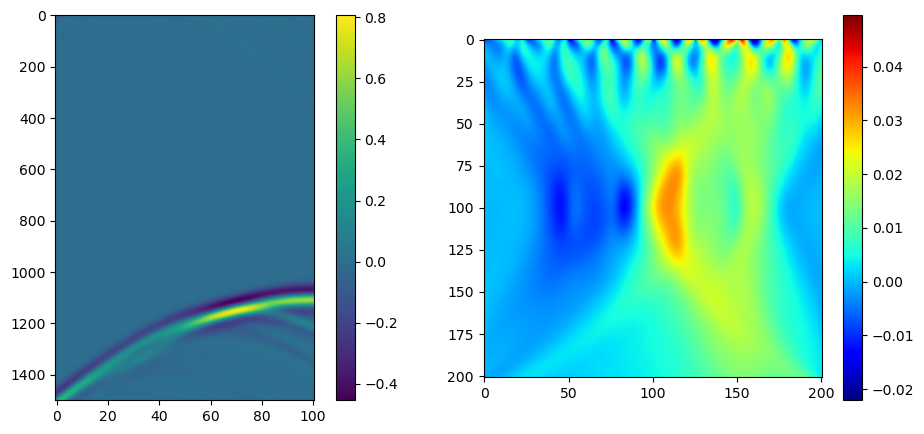

PyObject <matplotlib.colorbar.Colorbar object at 0x71bab7179950>

In [4]:
close()
figure(figsize=(12, 5))
subplot(121)
imshow(-data_true[:,:,9], aspect=0.1, cmap="viridis")
colorbar()
subplot(122)
imshow(reshape(-grad, 201, 201), cmap="jet")
colorbar()

In [9]:
close()
figure(figsize=(12, 5))
subplot(121)
imshow(reshape(x, 201, 201), clim=(800, 1200), cmap="seismic")
# imshow(reshape(x0-x1, 201, 201), cmap="jet")

colorbar()
subplot(122)
imshow(reshape(grad, 201, 201) .* 1e3, cmap="jet")
# imshow(reshape(grad0-grad1, 201, 201) .* 1e2, cmap="jet")

colorbar()
tight_layout()

# The prox algorithm may wrong.

LoadError: UndefVarError: `x` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

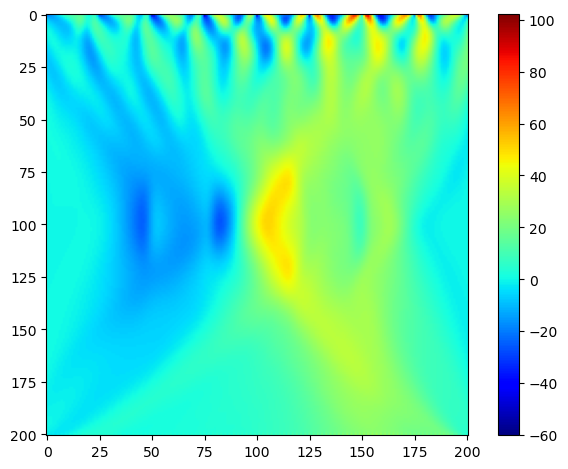

In [141]:
@load "temp_data/grad.jld2"
imshow(reshape(grad, 201, 201) .* 3e3, cmap="jet")
# imshow(reshape(grad0-grad1, 201, 201) .* 1e2, cmap="jet")

colorbar()
tight_layout()

In [101]:
a = [950., 1000., 1200.]
b = [950., 1000., 1200.]
# nu = 5e-4
nu = 0
lamb = 3e3
iterMax = 30

c = 1000 .* ones(201,201)

include("src/prox.jl")
eval_theta(x, a, b, nu)

0.0

In [96]:
@load "temp_data/true_data.jld2"


1-element Vector{Symbol}:
 :data_true

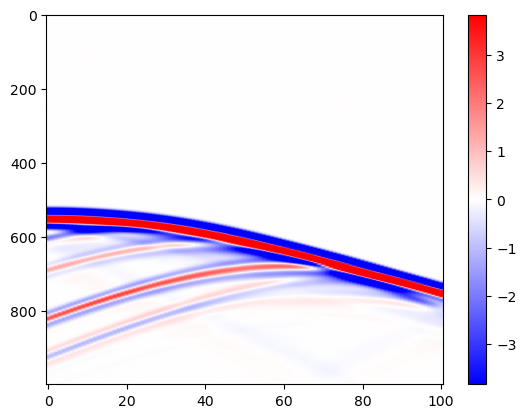

PyObject <matplotlib.colorbar.Colorbar object at 0x747c98a3c2d0>

In [97]:
val = maximum(abs.(data_true)) * 0.1
plt.close()
plt.imshow(data_true[:,:,1], aspect="auto", cmap="bwr", clim=(-val, val))
plt.colorbar()


In [5]:
val = maximum(abs.(grad)) * 0.2
plt.close()
plt.figure(figsize=(10, 3))
plt.imshow(reshape(grad, 175, 350), cmap="bwr", clim=(-val, val))
# plt.colorbar()

LoadError: UndefVarError: `grad` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

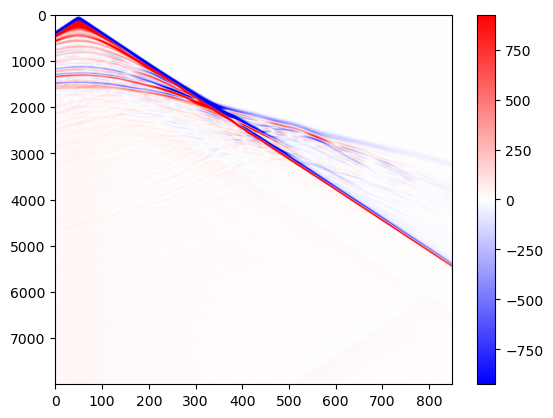

PyObject <matplotlib.colorbar.Colorbar object at 0x74d9491f3750>

In [14]:
val = maximum(abs.(data_true)) * 0.05
plt.close()
plt.imshow(data_true[:,:,1], aspect="auto", cmap="bwr", clim=(-val, val))
plt.colorbar()


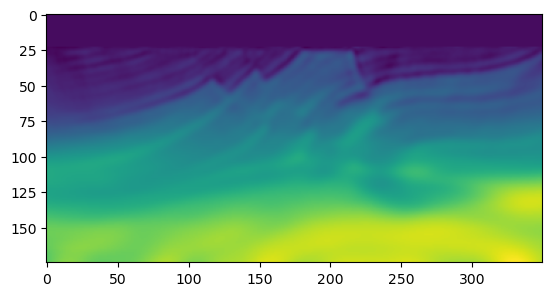

PyObject <matplotlib.image.AxesImage object at 0x72859db4ce10>

In [54]:
@load "temp_data/10.jld2"

plt.imshow(reshape(u1, 175, 350))
# plt.colorbar()


In [33]:
size(c)

(175, 850)

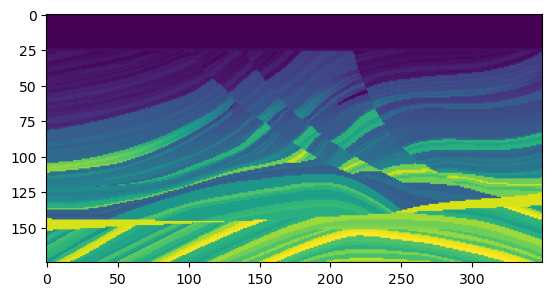

PyObject <matplotlib.image.AxesImage object at 0x7285a2fbc550>

In [19]:
@load "data/marmousi/marmousi20.jld2"

plt.imshow(c[:, 301:650])

In [27]:
c[1:24,1]

24-element Vector{Float64}:
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5
 1.5319995880126953

In [17]:
@load "data/marmousi/marmousi20.jld2"
c = 1000 .* c
rho = 1000 .* rho
c0 = imfilter(c, Kernel.gaussian(10));
c0[1:23,:] .= 1500.
Nx, Ny = size(c)
dx, dy = 20, 20
Nt = 8000
Fs = 500
dt = 1/Fs
t = range(0, (Nt-1)*dt, Nt)

source_num = 15
source_position = zeros(2,source_num)
for i = 1:source_num
    source_position[1,i] = 5
    source_position[2,i] = 51 + (i-1)*51
end

x = range(0, (Nx-1)*dx, Nx)
y = range(0, (Ny-1)*dy, Ny)
X = repeat(x, 1, Ny)
Z = repeat(y', Nx, 1)


175×850 Matrix{Float64}:
 0.0  20.0  40.0  60.0  80.0  100.0  …  16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0  …  16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0  …  16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0
 0.0  20.0  40.0  60.0  80.0  100.0     16920.0  16940.0  16960.0  16980.0


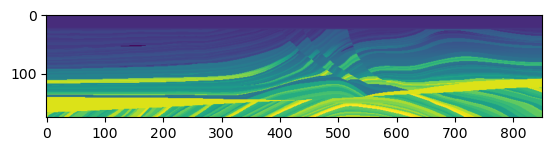

PyObject <matplotlib.image.AxesImage object at 0x74d948397110>

In [19]:
plt.imshow(c)

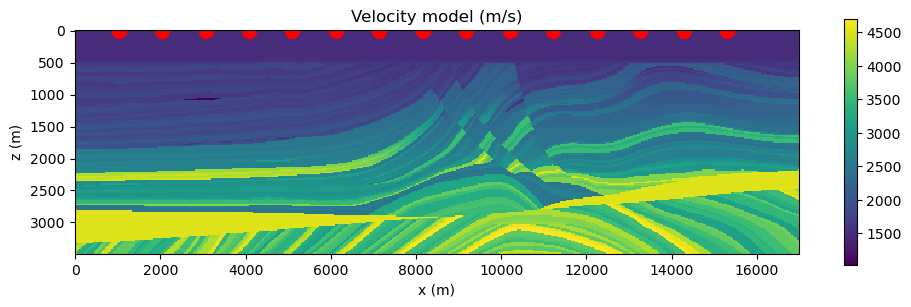

In [65]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.pcolormesh(Z, X, c, cmap="viridis")
ax.yaxis.set_inverted(true)
ax.scatter(source_position[2,:] * dx, source_position[1,:], color="red", s=100)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect(1.5)
plt.colorbar(im)
ax.set_title("Velocity model (m/s)")
plt.tight_layout()

fig.savefig("velocity_model.png", dpi=300)


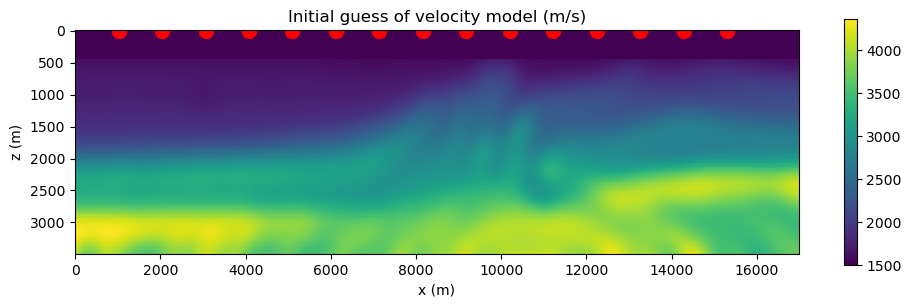

In [66]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.pcolormesh(Z, X, c0, cmap="viridis")
ax.yaxis.set_inverted(true)
ax.scatter(source_position[2,:] * dx, source_position[1,:], color="red", s=100)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect(1.5)
plt.colorbar(im)
ax.set_title("Initial guess of velocity model (m/s)")
plt.tight_layout()

fig.savefig("initial_model.png", dpi=300)


In [21]:
@load "forward_true.jld2"

2-element Vector{Symbol}:
 :data_true
 :U_true

(8000, 850)
(8000, 850)
(8000, 850)


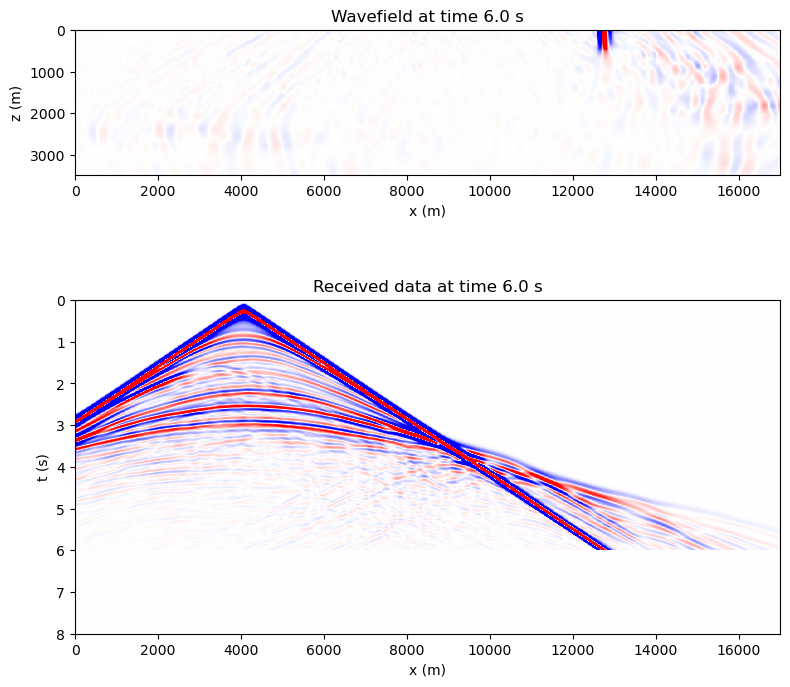

In [22]:
Xt = repeat(y', Nt, 1)
T = repeat(t, 1, Ny)

println(size(data_true))
println(size(Xt))
println(size(T))

idx_t = 2001

function plot_data_true(idx_t)
    val = maximum(abs.(data_true)) * 0.03
    plt.close()
    fig, (ax1, ax2) = plt.subplots(figsize=(8, 8), ncols=1, nrows=2)
    im1 = ax1.pcolormesh(Z, X, U_true[:,:,idx_t], cmap="bwr", clim=(-val, val))
    ax1.yaxis.set_inverted(true)
    ax1.set_xlabel("x (m)")
    ax1.set_ylabel("z (m)")
    ax1.set_aspect(1.)
    ax1.set_title("Wavefield at time $(t[idx_t]) s")

    data0 = 0 .* data_true
    data0[1:idx_t,:] = data_true[1:idx_t,:]
    im2 = ax2.pcolormesh(Xt, T, data0, cmap="bwr", clim=(-val, val))
    ax2.yaxis.set_inverted(true)
    ax2.set_ylim([8, 0])
    ax2.set_xlabel("x (m)")
    ax2.set_ylabel("t (s)")
    ax2.set_aspect(22 * Nt / Nx)
    # plt.colorbar(im)
    ax2.set_title("Received data at time $(t[idx_t]) s")

    plt.tight_layout()
    plt.savefig("data_true_" * string(idx_t) * ".png", dpi=300)

end

plot_data_true(3001)

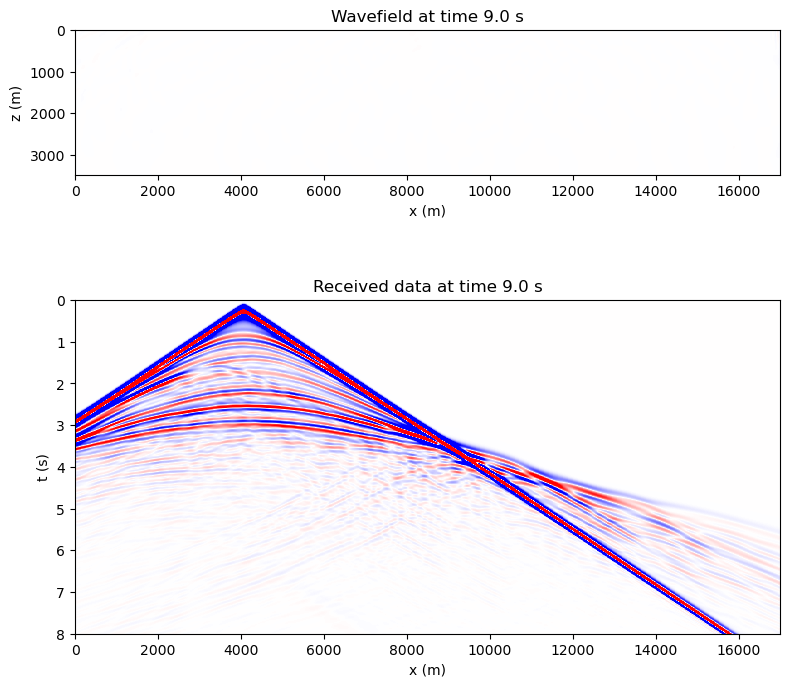

In [67]:
plot_data_true(501)
plot_data_true(1001)
plot_data_true(1501)
plot_data_true(2001)
plot_data_true(2501)
plot_data_true(3001)
plot_data_true(3501)
plot_data_true(4001)
plot_data_true(4501)

In [2]:
@load "adj_check_forward.jld2"
U_forward = U_save
@load "adj_check_forward_diff.jld2"
U_forward_diff = U_save
@load "adj_check_backward.jld2"
U_backward = U_save
@load "adj_check_after_inner.jld2"
U_after_inner = U_save;

In [70]:
idx1 = 501
idx2 = 1001
idx3 = 1501
idx4 = 2001

function plot_wavefield(U, savename, title_name; ratio=0.03)

    val = maximum(abs.(U)) * ratio
    plt.close()
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(figsize=(12, 4), ncols=2, nrows=2, sharex=true, sharey=true)

    im1 = ax1.pcolormesh(Z, X, U[:,:,idx1], cmap="bwr", clim=(-val, val))
    ax1.yaxis.set_inverted(true)
    # ax1.set_xlabel("x (m)")
    ax1.set_ylabel("z (m)")
    ax1.set_aspect(1.)
    ax1.set_title(title_name * "at time $(t[idx1]) s")

    im2 = ax2.pcolormesh(Z, X, U[:,:,idx3], cmap="bwr", clim=(-val, val))
    ax2.yaxis.set_inverted(true)
    ax2.set_xlabel("x (m)")
    ax2.set_ylabel("z (m)")
    ax2.set_aspect(1.)
    ax2.set_title(title_name * "at time $(t[idx3]) s")

    im3 = ax3.pcolormesh(Z, X, U[:,:,idx2], cmap="bwr", clim=(-val, val))
    ax3.yaxis.set_inverted(true)
    # ax3.set_xlabel("x (m)")
    # ax3.set_ylabel("z (m)")
    ax3.set_aspect(1.)
    ax3.set_title(title_name * "at time $(t[idx2]) s")

    im4 = ax4.pcolormesh(Z, X, U[:,:,idx4], cmap="bwr", clim=(-val, val))
    ax4.yaxis.set_inverted(true)
    ax4.set_xlabel("x (m)")
    # ax4.set_ylabel("z (m)")
    ax4.set_aspect(1.)
    ax4.set_title(title_name * "at time $(t[idx4]) s")

    plt.tight_layout()
    plt.savefig(savename*".png", dpi=300)

end


plot_wavefield (generic function with 2 methods)

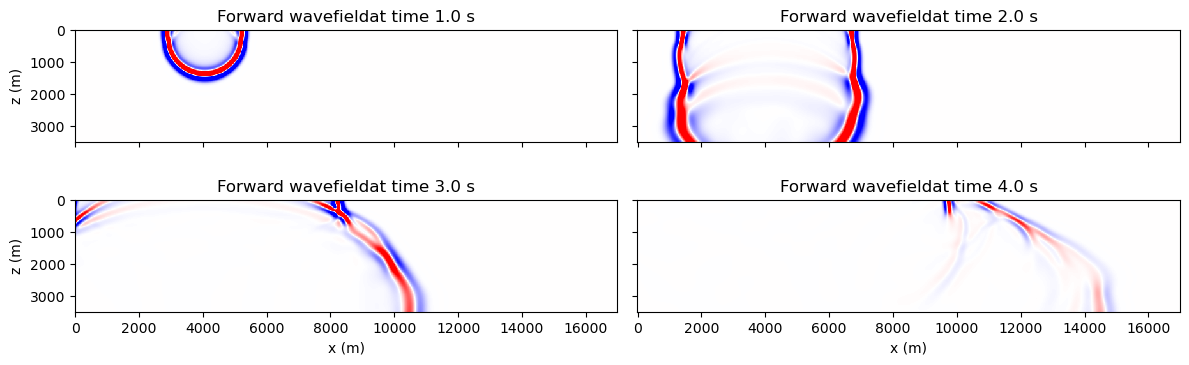

In [71]:
plot_wavefield(U_forward, "wavefield_forward", "Forward wavefield")

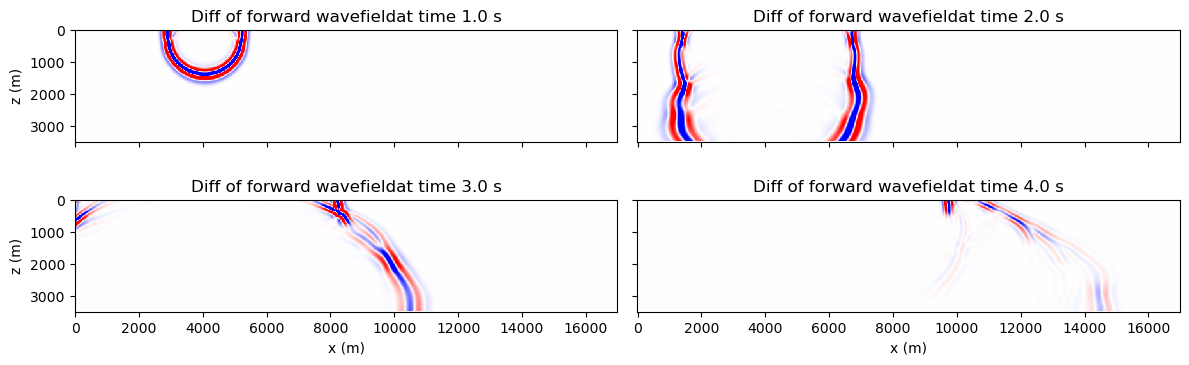

In [72]:
plot_wavefield(U_forward_diff, "wavefield_forward_diff", "Diff of forward wavefield")


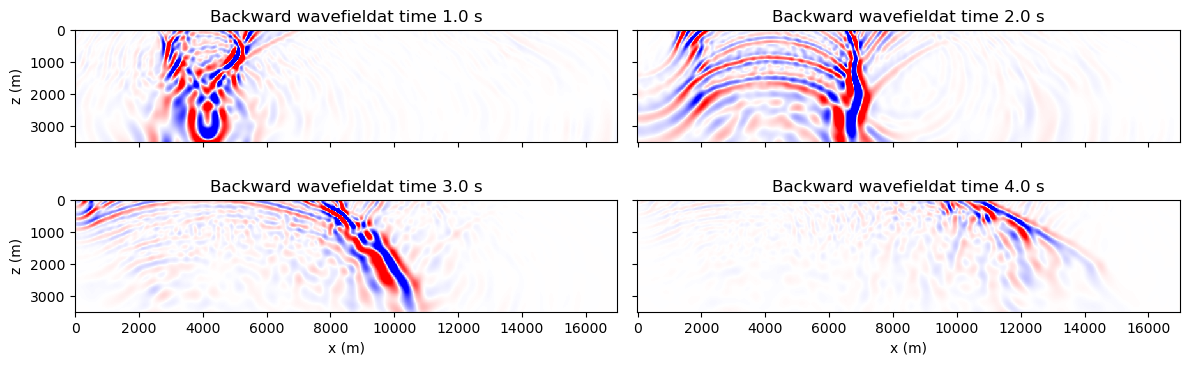

In [73]:
plot_wavefield(reverse(U_backward, dims=3), "wavefield_backward", "Backward wavefield", ratio=0.1)


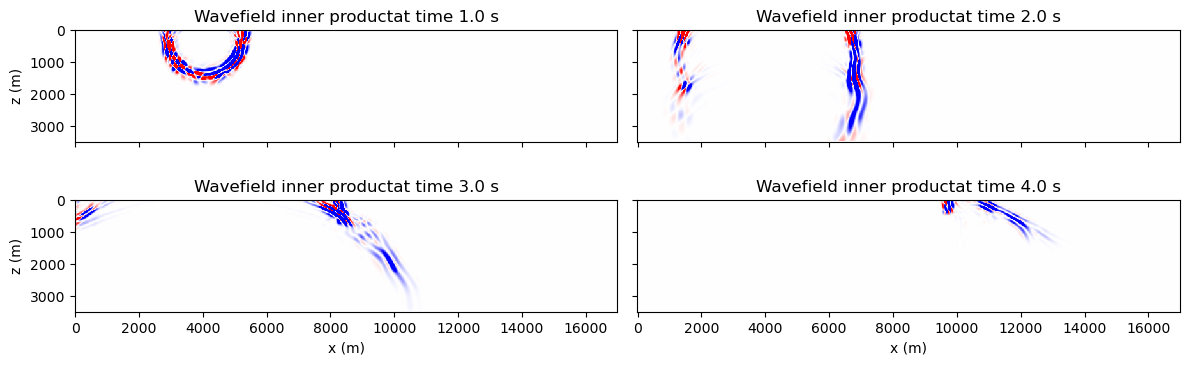

In [74]:
plot_wavefield(-2 ./ c0.^3 .*U_after_inner, "wavefield_after_inner", "Wavefield inner product", ratio=0.002)

In [49]:
@load "grad.jld2" 
size(grad)

(175, 850)

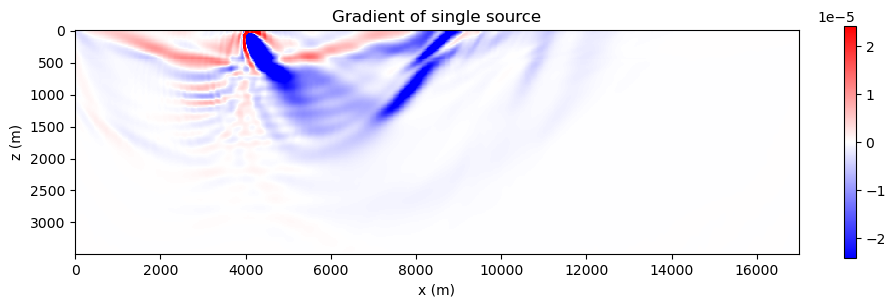

In [56]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 3))
val = maximum(abs.(grad)) * 0.1
im = ax.pcolormesh(Z, X, grad, cmap="bwr", clim=(-val, val))
ax.yaxis.set_inverted(true)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect(1.5)
plt.colorbar(im)
ax.set_title("Gradient of single source")
plt.tight_layout()

fig.savefig("grad_single_source.png", dpi=300)

In [60]:
@load "grad_all_source.jld2" 
grad_all_source = grad_all_source';

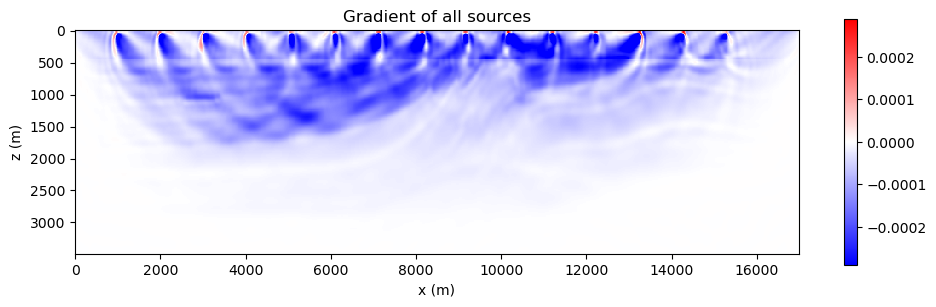

In [64]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 3))
val = maximum(abs.(grad_all_source)) * 0.15
im = ax.pcolormesh(Z, X, grad_all_source, cmap="bwr", clim=(-val, val))
ax.yaxis.set_inverted(true)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect(1.5)
plt.colorbar(im)
ax.set_title("Gradient of all sources")
plt.tight_layout()

fig.savefig("grad_all_sources.png", dpi=300)